# Commerce Delivery Intelligence
### Delivery reliability, customer experience and purchase-time risk

**Decision:** Where should a marketplace investigate delivery reliability, and
what information available at checkout helps identify future delays?

This analysis uses Olist's original public Kaggle data. It connects order,
customer, item, seller, product and review tables at the **order** grain.
The executed results, charts and feature diagnostics below are reproducible
from the modular Python package. Monetary amounts are nominal Brazilian reais
(BRL). Dates are source-local timestamps; no unsupported timezone is imposed.

Read the executive findings first, then follow the evidence and limitations.
Dataset: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

In [1]:
from pathlib import Path
import sys

# Works from the repository root or its notebooks/ directory.
ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise RuntimeError("Open this notebook inside the cloned repository.")
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import Image, Markdown, display
from commerce_intelligence.cli import run_project
from commerce_intelligence.modeling import FEATURES, NUMERIC, chronological_split

# Download separately with `commerce-insights download` if raw files are absent.
# This analytical run is offline and does not scrape live listings.
result = run_project(ROOT)
orders = result["orders"]
audit = result["audit"]
model = result["model"]
display(Markdown((ROOT / "reports/executive_summary.md").read_text()))

# Delivery reliability: executive findings

## Evidence

- The valid delivered cohort contains **96,470 orders**, purchased from
  2016-09-15 through 2018-08-29. **6.8%** arrived after
  their promised calendar date. Median delivery time was
  **10.2 days**.
- Reviews cover **99.3%** of the cohort. Among reviewed orders,
  ratings of 1-2 occur in **62.4%** of late deliveries
  versus **9.3%** of on-time deliveries.
  The difference is **53.2 percentage points**
  (95% order-level bootstrap interval: **51.9-54.4 points**).
- Among states with at least 500 orders, **MA** has the highest observed
  late rate, **17.4%**, on **717** orders.
  Inspect the Wilson intervals before prioritizing a small state over a large one.
- A purchase-time logistic benchmark achieves out-of-time ROC AUC
  **0.715**, average precision **0.076**,
  and Brier score **0.0331**. Test late prevalence is
  **3.5%**. See metrics.json for the baseline
  and MI comparison.
- PCA retains **10** components to explain at least
  90% of training variance across 15 standardized numeric inputs.

## Decisions supported

1. Audit routes in high-volume states with elevated late rates; measure carrier
   capacity and promise accuracy before changing operations.
2. Pilot proactive communication for at-risk deliveries. Evaluate intervention
   effects with a randomized experiment and track dissatisfaction, cost and retention.
3. Monitor monthly rate drift and calibration before using the benchmark as a
   decision service. Set thresholds using intervention costs, not arbitrary accuracy.

## Interpretation boundaries

This is historical observational evidence, not a causal estimate. Review response
and delivery completion select the population; canceled and undelivered orders are
excluded. Order-level intervals assume independence and do not account for repeated
customers or shared carrier shocks. Month-edge cohorts can be incomplete. State is
a routing proxy, not a cause. The dataset is historical Brazilian marketplace data,
so findings should not be generalized to current operations or Iran.

The model is an analytical benchmark, not a deployed prediction service. Seller
assignment and shipping quote are assumed known at checkout; validate this timing
in a real platform. Never feed delivery timestamps, delay, reviews, or identifiers
into purchase-time prediction. Test outcomes do not tune feature selection or PCA.


## 1. Source quality and analysis population

Olist provides real multi-table ecommerce transactions with operational dates,
amounts and customer ratings. This supports routing economics and reliability
analysis more directly than a flat synthetic sales table. No Iranian Kaggle
dataset was selected: the core question benefits from Olist's documented event
sequence and relational structure. The independent Samand extension adds a
local market acquisition example without mixing unrelated data into the model.

We remove exact duplicate rows and fail on conflicting entity/item primary keys.
Missing or invalid dates are parsed to missing values. Nonpositive item prices,
negative freight and nonpositive product weights become missing. Monetary totals
with invalid items stay missing. Reviews can repeat per order: the latest
answered review wins, with review ID as a deterministic tie-breaker.

Item counts and seller counts are aggregated **before** one-to-one order joins.
Customers, sellers and products use validated many-to-one joins. The cohort
requires delivered status and plausible purchase, delivery and estimated dates.
Missing reviews remain unavailable and do not become good ratings. Numerical
features use train-only median imputation; categories use the training mode.
No outliers are removed merely because they are large.

In [2]:
quality = pd.DataFrame({
    name: {"source_rows": value["rows"],
           "exact_duplicates": value["exact_duplicates"],
           "missing_cells": sum(value["missing"].values())}
    for name, value in audit["tables"].items()
}).T
display(quality)
display(pd.Series(audit["status_counts"], name="source_order_status"))
display(pd.Series({
    "excluded_orders": audit["excluded_from_delivered_cohort"],
    "retained_orders": audit["cohort_rows"],
    "invalid_price_items": audit["invalid_price_items"],
    "extra_review_rows": audit["extra_review_rows"],
}, name="cleaning_audit"))
display(orders[FEATURES + ["review_score"]].isna().mean()
        .sort_values(ascending=False).rename("missing_share").to_frame())
display(orders[NUMERIC + ["delivery_days", "delay_days"]]
        .describe(percentiles=[.01, .5, .95, .99]).T.round(2))
assert orders.order_id.is_unique

,source_rows,exact_duplicates,missing_cells
orders,99441,0,4908
items,112650,0,0
customers,99441,0,0
sellers,3095,0,0
products,32951,0,2448
reviews,99224,0,145903


delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: source_order_status, dtype: int64

excluded_orders         2971
retained_orders        96470
invalid_price_items        0
extra_review_rows        551
Name: cleaning_audit, dtype: int64

,missing_share
review_score,0.006696
weight_g,0.000228
purchase_hour,0.000000
value_band,0.000000
customer_state,0.000000
weekend,0.000000
month_cos,0.000000
month_sin,0.000000
weekday,0.000000
item_value,0.000000


,count,mean,std,min,1%,50%,95%,99%,max
item_value,96470.0,137.04,209.05,0.85,11.99,86.50,399.00,990.00,13440.00
freight,96470.0,22.79,21.56,0.00,7.39,17.17,54.78,104.25,1794.96
item_count,96470.0,1.14,0.54,1.00,1.00,1.00,2.00,3.00,21.00
seller_count,96470.0,1.01,0.12,1.00,1.00,1.00,1.00,2.00,5.00
weight_g,96448.0,2387.02,4770.22,2.00,100.00,750.00,10500.00,22350.00,184400.00
interstate_share,96470.0,0.64,0.48,0.00,0.00,1.00,1.00,1.00,1.00
promised_days,96470.0,23.74,8.76,2.01,6.05,23.23,38.42,50.21,155.14
freight_ratio,96470.0,0.31,0.31,0.00,0.03,0.22,0.84,1.46,21.45
log_value,96470.0,4.46,0.92,0.62,2.56,4.47,5.99,6.90,9.51
value_per_item,96470.0,125.23,189.70,0.85,10.99,79.00,364.00,899.90,6735.00


## 2. Delivery patterns and customer experience

**Definition:** an order is late if its actual delivery calendar date is after
the estimated delivery date. A delivery at 23:00 on the promised date is on time.
`delivery_days` uses elapsed time; `delay_days` uses calendar dates.

The chart sequence separates frequency, distribution and time. The donut pie
chart gives the outcome share. The box plot hides fliers to reveal central spread
but retains every valid row in estimates. Volume and multi-line duration charts
use purchase cohorts, avoiding the misleading comparison of sales and delivery
months. First and last months can be incomplete.

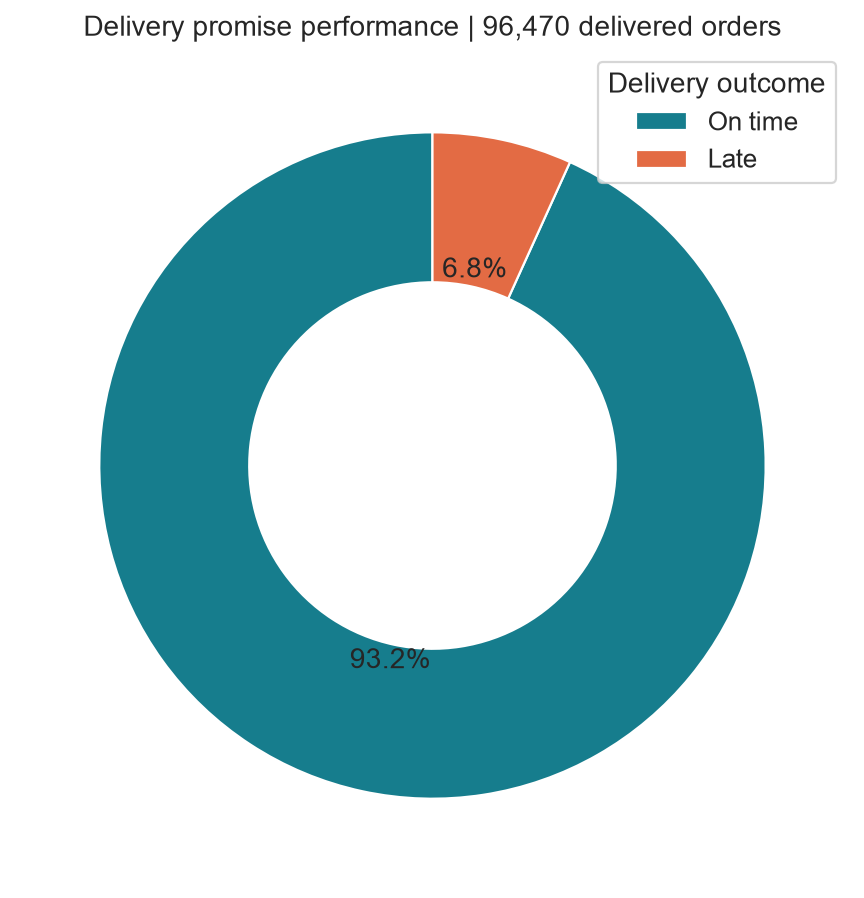

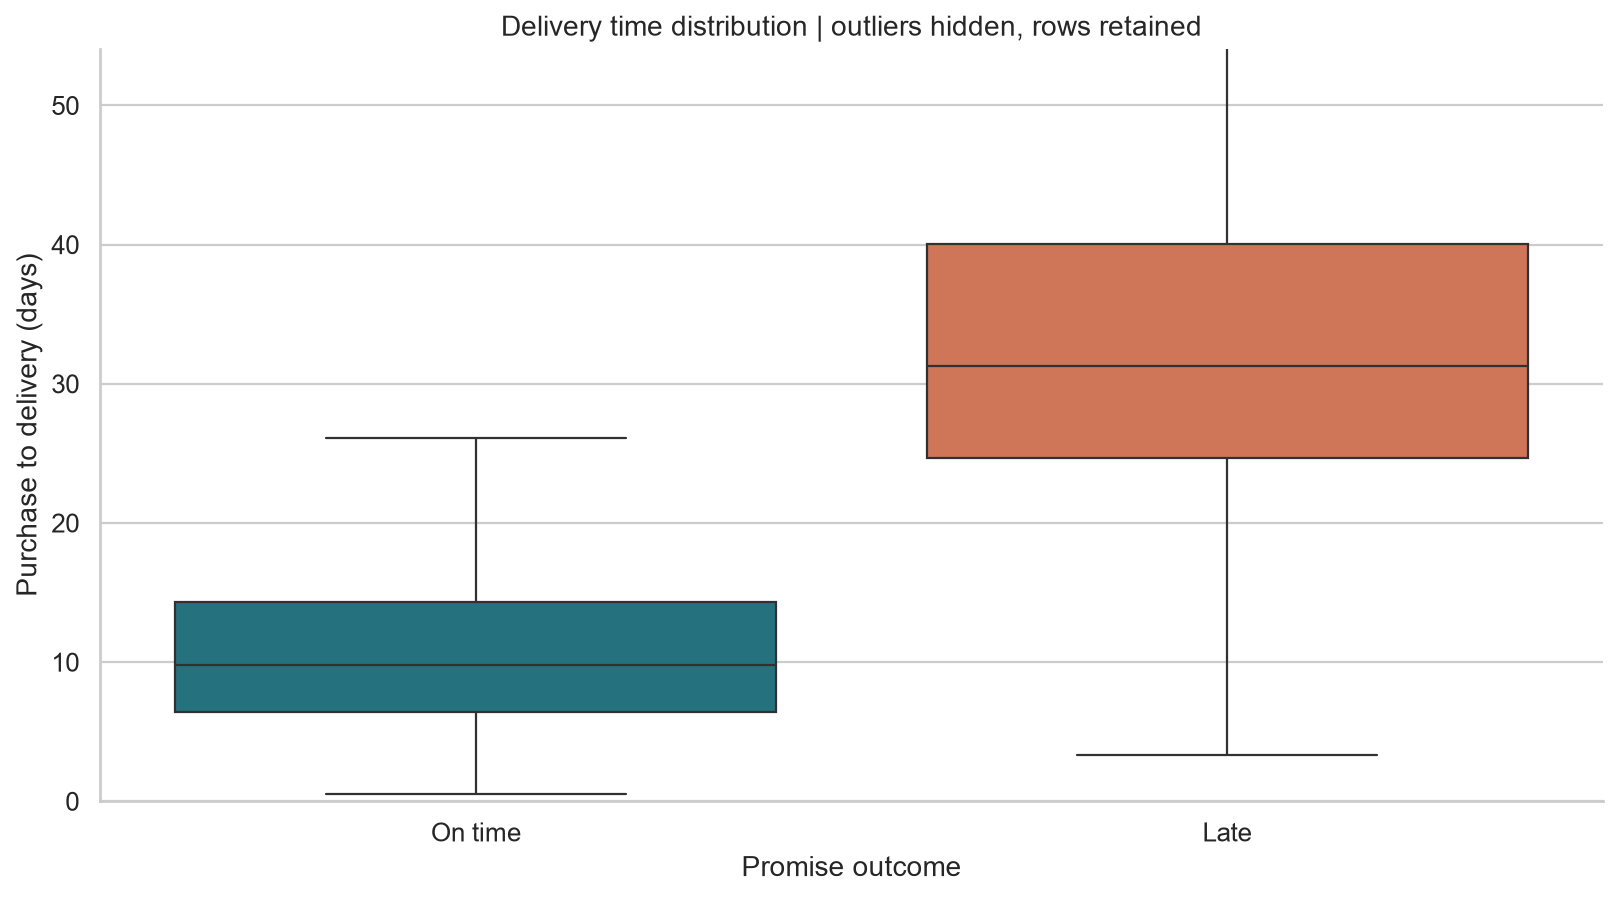

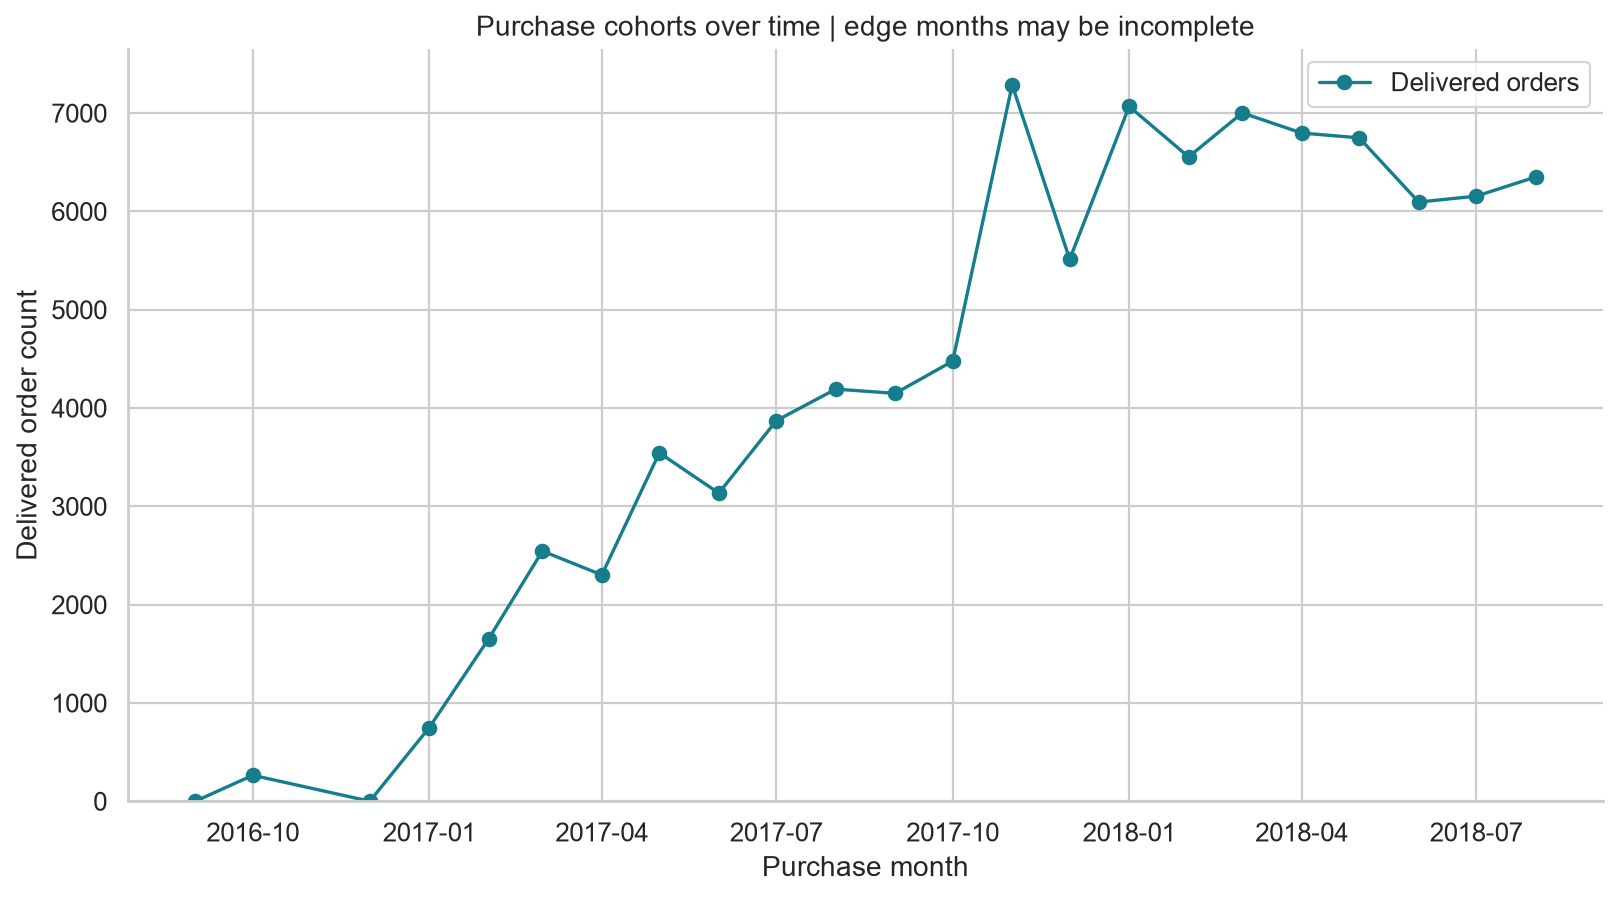

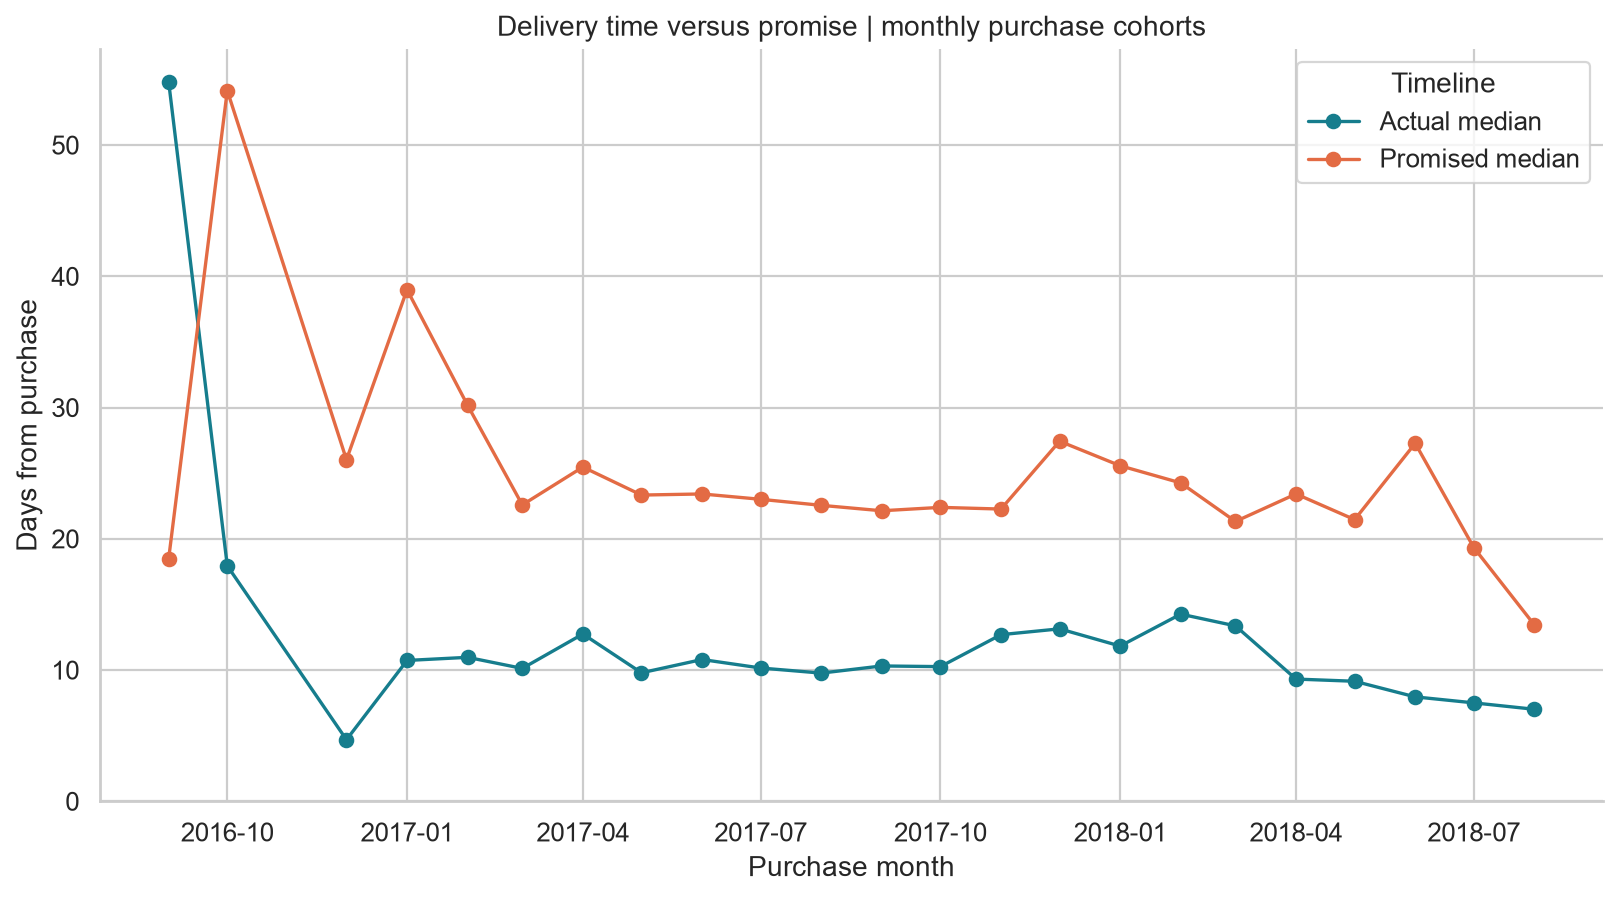

In [3]:
def show_chart(name):
    display(Image(filename=str(ROOT / "reports/figures" / name)))

for name in ["01_delivery_share.png", "02_delivery_box.png",
             "03_monthly_volume.png", "04_delivery_trends.png"]:
    show_chart(name)

The destination bar chart establishes business scale. Grouped rating counts show
volume; stacked proportions make rating mixes comparable despite unequal cohort
sizes. Reviews are selected responses and can precede delivery, so the observed
rating gap does not establish that lateness caused dissatisfaction.

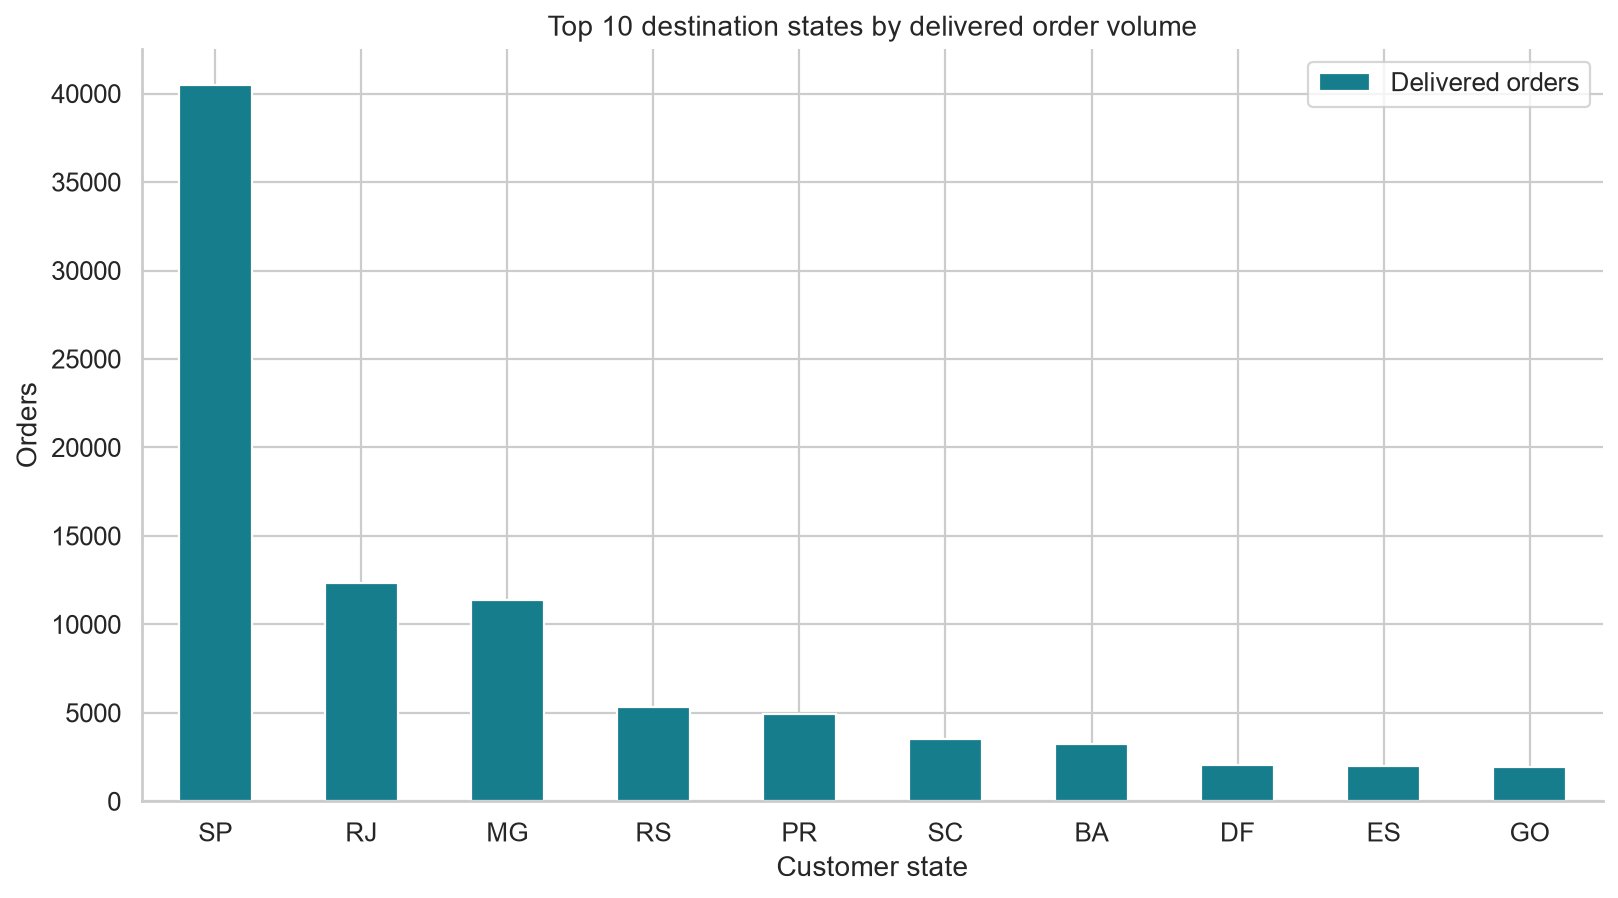

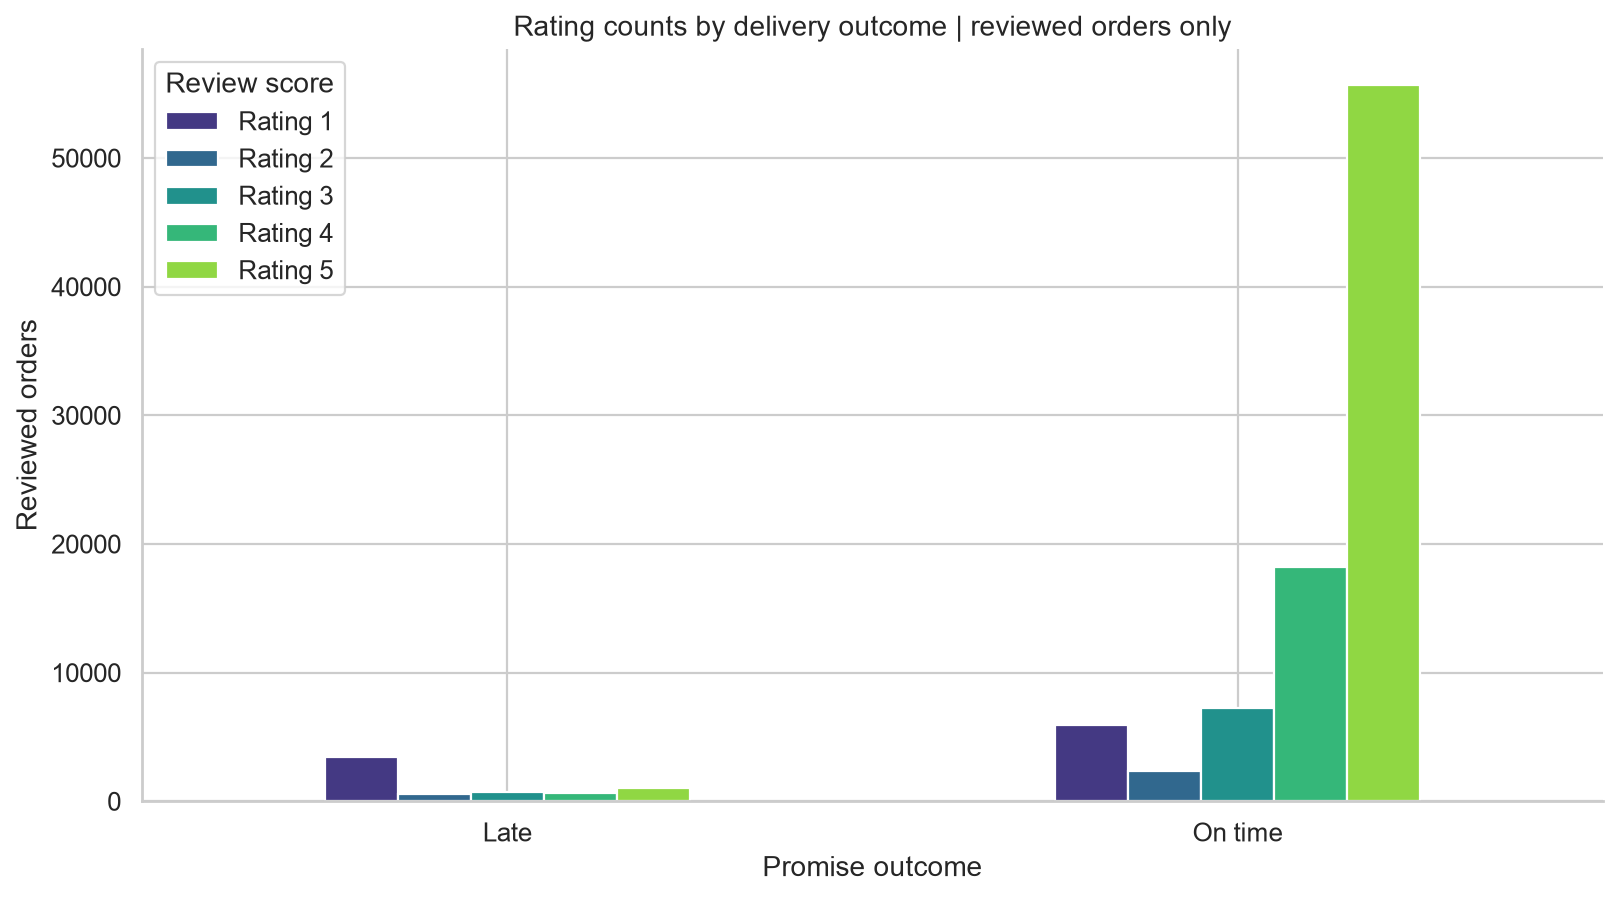

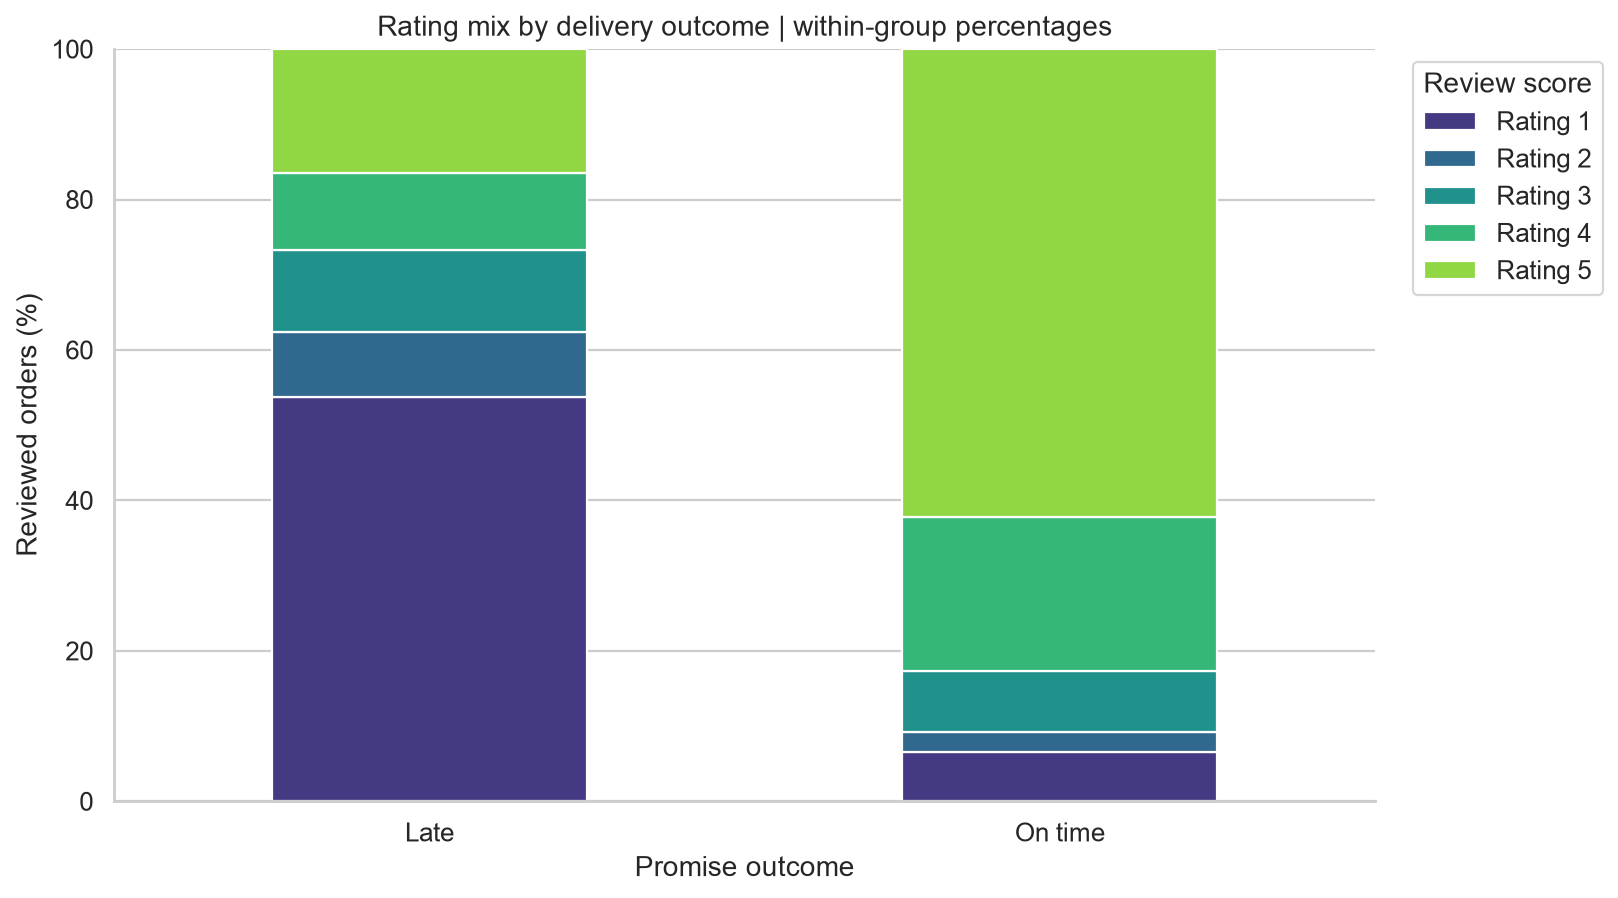

,sum,count,mean,lower,upper
late,,,,,
On time,8289,89443,0.092674,0.090791,0.094591
Late,3983,6381,0.624197,0.612242,0.636002


In [4]:
for name in ["05_state_volume.png", "06_grouped_reviews.png",
             "07_stacked_reviews.png"]:
    show_chart(name)
display(result["summary"]["reviews"].rename(index={0: "On time", 1: "Late"}))

## 3. Routing economics and uncertainty

The seeded scatter sample relates promise duration to realized delivery. Visible
axes stop at the full cohort's 99.5th percentile; extreme values remain in the
statistics. The equality line is a duration reference, while the official target
uses calendar dates. State bubbles combine freight, late rate, order volume and
median delivery time. Bubble **area** scales with order count.

State error bars are 95% Wilson intervals, restricted to destinations with at
least 500 delivered orders. Ranking states is descriptive, without correction
for multiple comparisons. The review risk difference uses a seeded 10,000-draw
order-level bootstrap (empirical Bernoulli resampling). Repeated customers and
common carrier shocks can make these intervals too narrow. A production study
should use customer/carrier clusters and check review nonresponse.

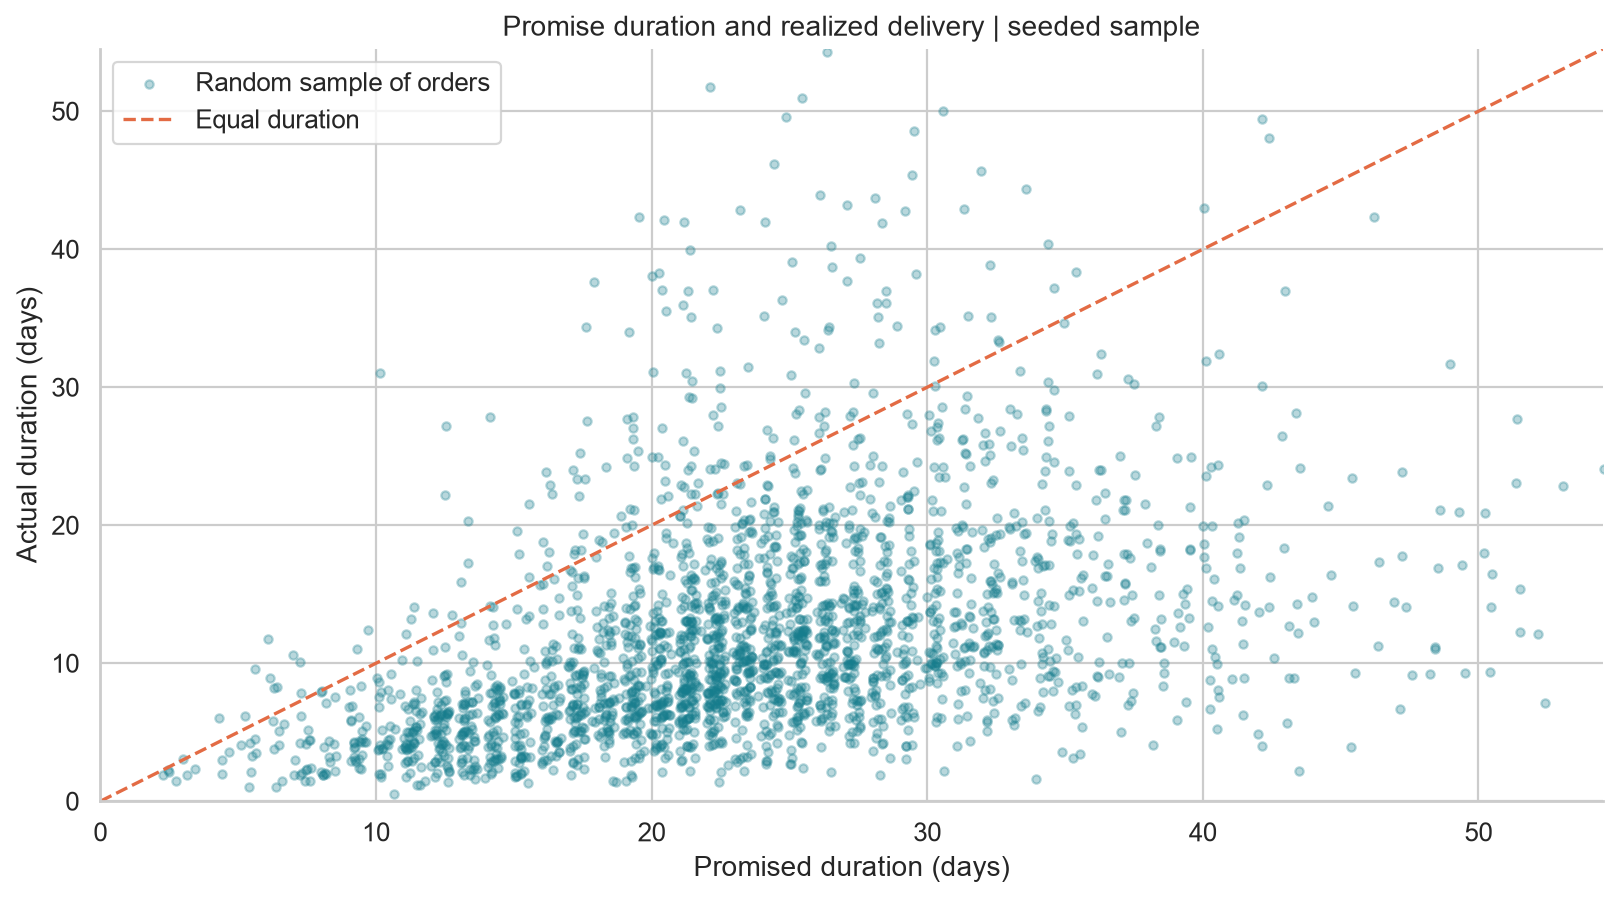

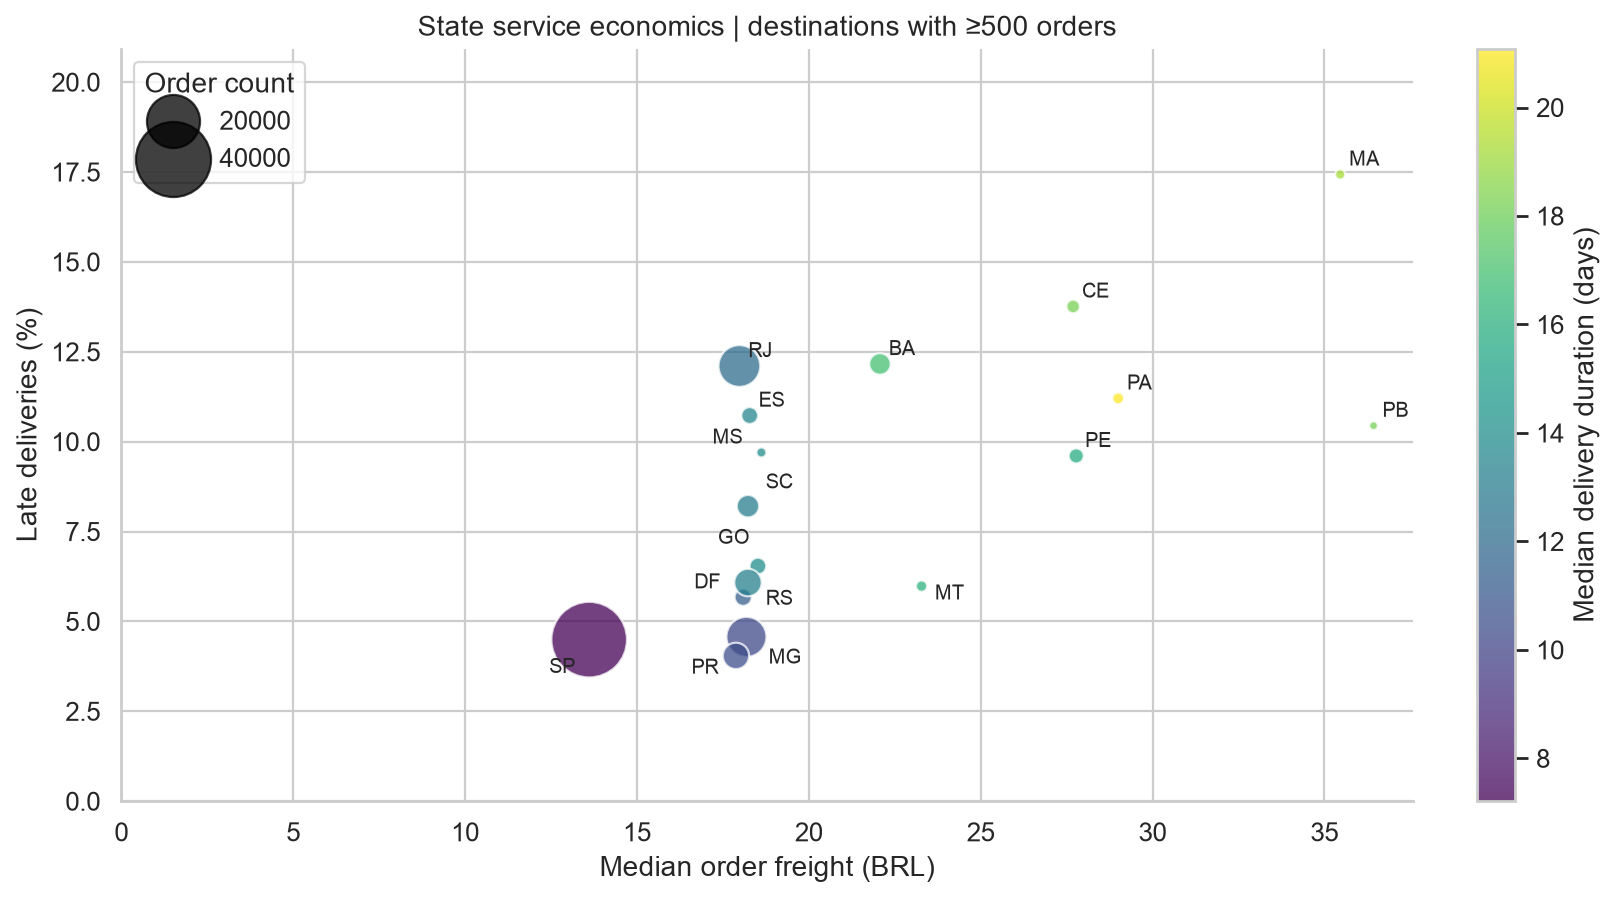

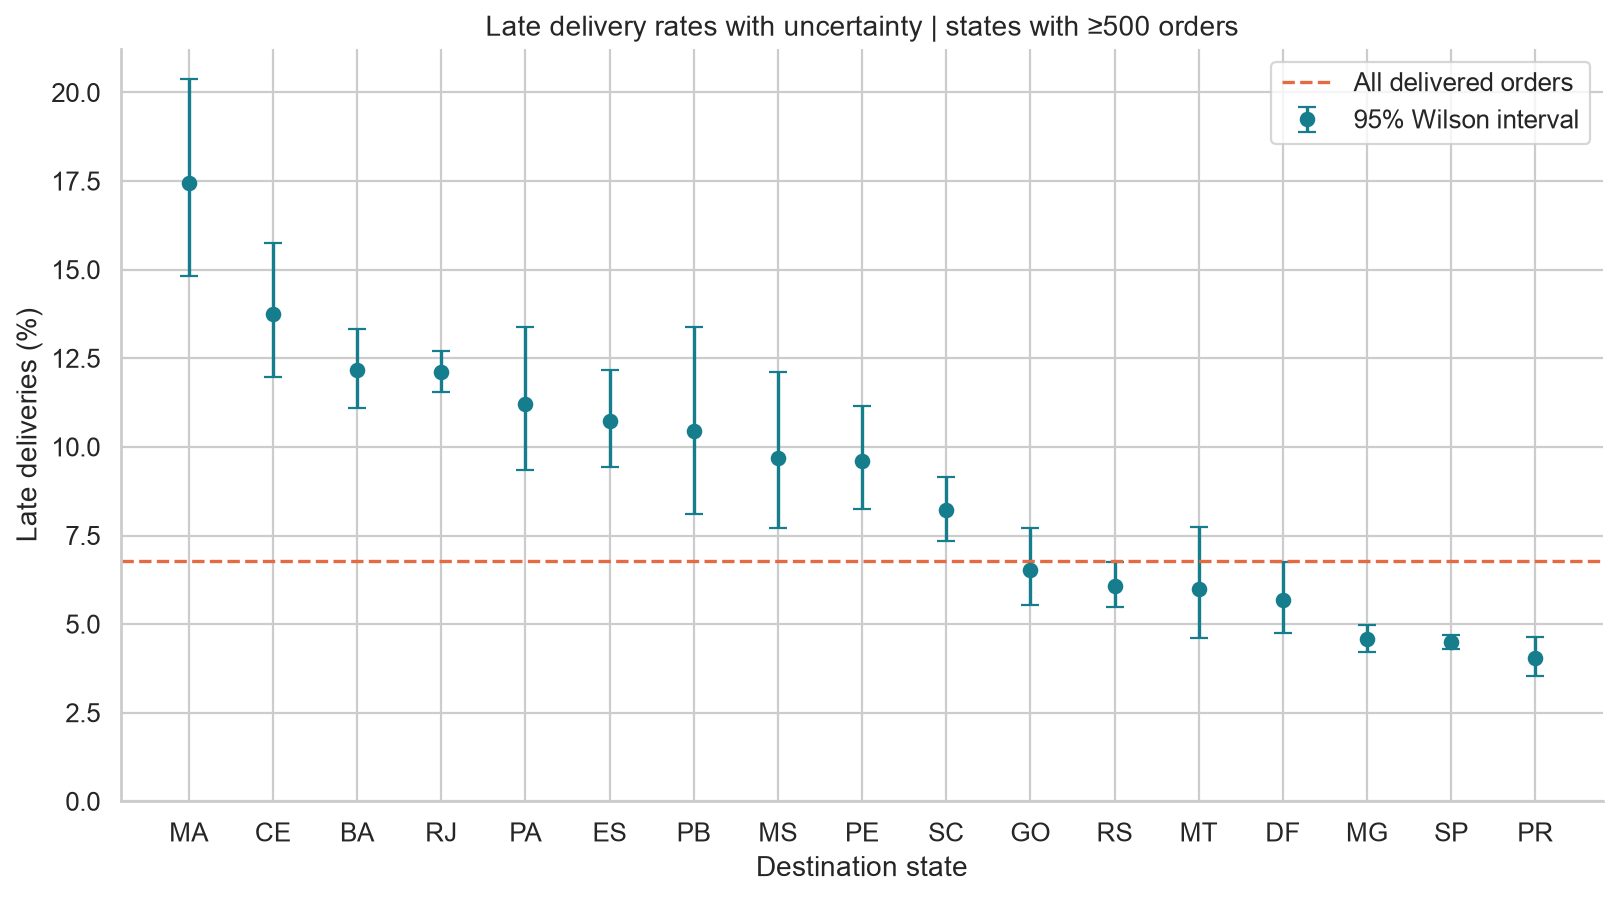

,sum,count,mean,lower,upper
customer_state,,,,,
MA,125,717,0.1743,0.1483,0.2038
CE,176,1279,0.1376,0.1198,0.1576
BA,396,3256,0.1216,0.1108,0.1333
RJ,1495,12350,0.1211,0.1154,0.1269
PA,106,946,0.1121,0.0935,0.1337
ES,214,1995,0.1073,0.0944,0.1216
PB,54,517,0.1044,0.0809,0.1338
MS,68,701,0.0970,0.0772,0.1212
PE,153,1593,0.0960,0.0825,0.1115


In [5]:
for name in ["08_promise_scatter.png", "09_state_bubbles.png",
             "10_state_uncertainty.png"]:
    show_chart(name)
display(result["summary"]["states"].round(4))

### Interactive route explorer

Hover to inspect a state's volume and economics, zoom into overlapping points,
and compare destination service levels. A self-contained offline HTML export is
saved under `reports/interactive/route_explorer.html`.

In [6]:
# GitHub may not render Plotly outputs; the preceding PNGs remain readable there.
display(result["interactive"])

## 4. Feature engineering and numerical preprocessing

| Family | Features | Analytical purpose |
|---|---|---|
| Ratios | freight/value, value/item | Shipping burden and basket economics |
| Fixed bins | 50, 150, 500 BRL cutoffs | Spending segments |
| Mathematical | log(1 + value) | Compress a heavy monetary tail |
| Combinations | interstate item share | Combine customer and seller routing geography |
| Date/time | hour, weekday, weekend, cyclical month | Calendar context |
| Aggregates | item/seller counts, value, freight, weight sums | Order grain |

Fixed bins are defined before observing the target. No future customer history or
target-encoded seller averages are used. IDs are join keys, and event dates are
converted into meaningful numerical inputs. We exclude raw IDs, free text and
post-purchase outcomes from the design matrix. All **model inputs** become numeric:
one-hot state/value-band encoding, median/mode imputation and numeric z-scores.
PCA operates on standardized numeric inputs so grams do not dominate BRL or counts.

In [7]:
display(orders[["item_value", "freight_ratio", "value_per_item", "value_band",
                "interstate_share", "item_count", "seller_count", "month_sin"]].head())
display(model["encoded_sample"].round(3))
print("Encoded numerical inputs:", model["metrics"]["encoded_feature_count"])

,item_value,freight_ratio,value_per_item,value_band,interstate_share,item_count,seller_count,month_sin
0,134.97,0.062903,44.99,standard,1.0,3.0,1.0,-1.000000
1,29.90,0.520401,29.90,budget,1.0,1.0,1.0,-0.866025
2,21.90,0.784932,21.90,budget,1.0,1.0,1.0,-0.866025
3,36.49,0.472458,36.49,budget,1.0,1.0,1.0,-0.866025
4,119.90,0.113094,119.90,standard,0.0,1.0,1.0,-0.866025


,num__item_value,num__freight,num__item_count,num__seller_count,num__weight_g,num__interstate_share,num__promised_days,num__freight_ratio,num__log_value,num__value_per_item,...,cat__customer_state_RR,cat__customer_state_RS,cat__customer_state_SC,cat__customer_state_SE,cat__customer_state_SP,cat__customer_state_TO,cat__value_band_budget,cat__value_band_high_value,cat__value_band_premium,cat__value_band_standard
0,-0.005,-0.679,3.405,-0.108,0.111,0.737,-0.724,-0.774,0.500,-0.427,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,-0.519,-0.328,-0.264,-0.108,-0.440,0.737,-0.089,0.691,-1.118,-0.508,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,-0.558,-0.247,-0.264,-0.108,-0.420,0.737,1.241,1.537,-1.446,-0.551,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.486,-0.244,-0.264,-0.108,-0.345,0.737,3.955,0.537,-0.907,-0.473,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.079,-0.427,-0.264,-0.108,-0.083,-1.361,3.204,-0.613,0.372,-0.024,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5,-0.518,-0.556,-0.264,-0.108,1.336,-1.361,3.202,0.195,-1.115,-0.508,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
6,-0.035,0.174,-0.264,-0.108,1.093,0.737,4.196,-0.338,0.450,0.025,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7,-0.299,-0.238,-0.264,-0.108,-0.134,0.737,3.449,-0.233,-0.137,-0.266,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Encoded numerical inputs: 46


## 5. Mutual information and temporal generalization

Split at the purchase date around the 80th percentile and hold all later dates
out. Training orders must also have been delivered before the cutoff, so labels
are known at training time. Preprocessing, MI selection and PCA fit **only** on
this training population. The later cohort is evaluated once.

MI captures nonlinear marginal dependence, not causal effects or conditional
incremental usefulness. Use at most 15,000 seeded training rows, mark count and
calendar variables as discrete, and keep one-hot indicators discrete. Select
the top 12 encoded inputs under a fixed rule. Compare that benchmark with a
logistic model using all inputs and a constant training-prevalence baseline.

ROC AUC measures ranking; average precision is informative with rare late orders;
Brier score evaluates probability error (lower is better). Calibration curves
show whether probabilities transport across time. A random split would obscure
the changes in delay prevalence and seasonality visible in the date cohorts.

,roc_auc,average_precision,brier_score
prevalence_baseline,0.5000,0.0348,0.0349
logistic_all,0.7150,0.0757,0.0331
logistic_mi12,0.6541,0.0574,0.0335


train_rows                       75099
test_rows                        19363
train_end          2018-05-24 12:28:44
test_start         2018-05-26 00:14:44
train_late_rate               0.071026
test_late_rate                0.034809
dtype: object

,feature,mutual_information
13,num__month_cos,0.01184
12,num__month_sin,0.00866
1,num__freight,0.00714
5,num__interstate_share,0.00617
33,cat__customer_state_RJ,0.00538
40,cat__customer_state_SP,0.00420
8,num__log_value,0.00262
0,num__item_value,0.00209
7,num__freight_ratio,0.00175
6,num__promised_days,0.00166


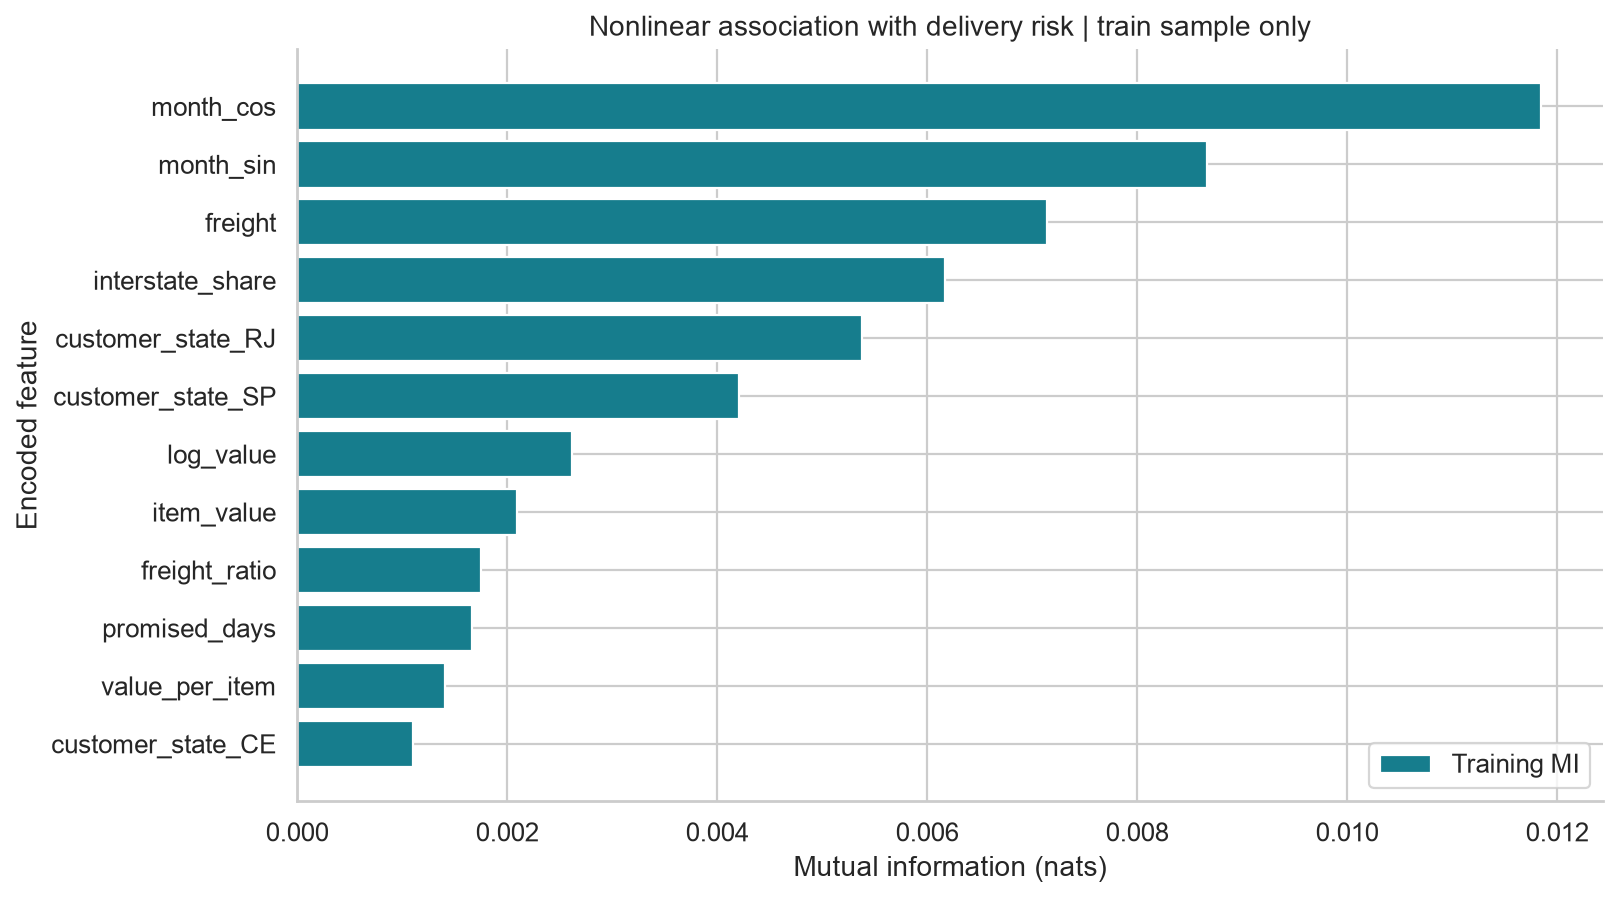

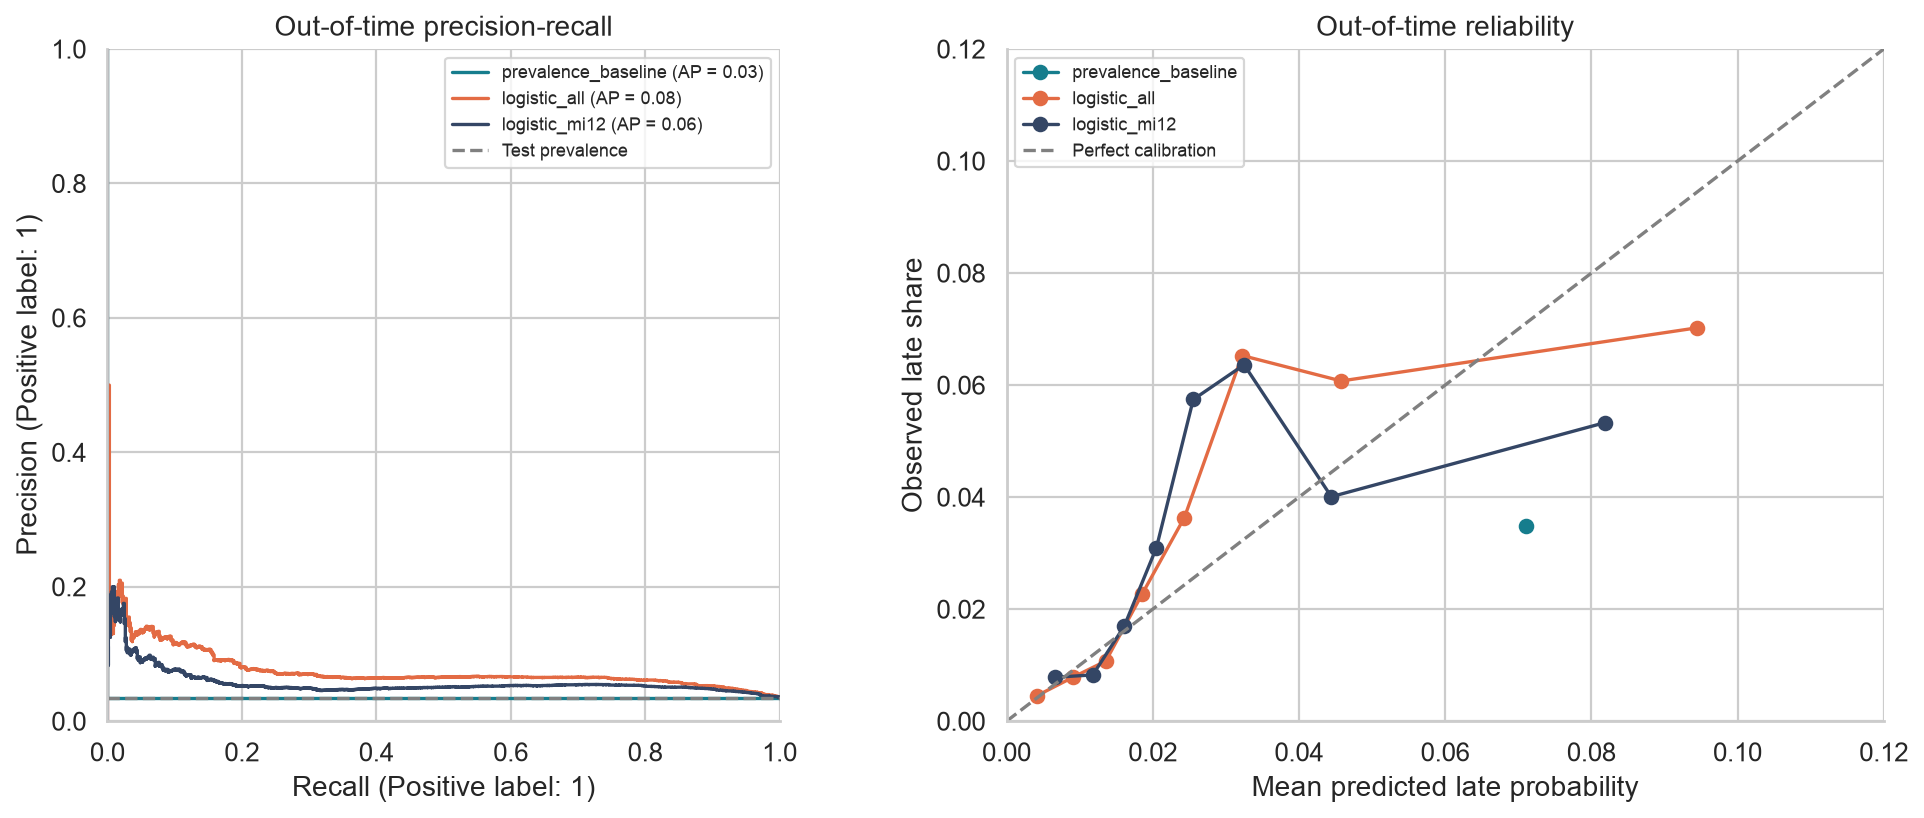

In [8]:
train, test = chronological_split(orders)
assert train.order_delivered_customer_date.max() < test.order_purchase_timestamp.min()
display(pd.DataFrame(model["metrics"]["models"]).T.round(4))
display(pd.Series({k: model["metrics"][k] for k in [
    "train_rows", "test_rows", "train_end", "test_start",
    "train_late_rate", "test_late_rate"]}))
display(model["ranking"].head(15).round(5))
show_chart("11_mutual_information.png")
show_chart("13_model_validation.png")

In [9]:
all_metrics = model["metrics"]["models"]["logistic_all"]
mi_metrics = model["metrics"]["models"]["logistic_mi12"]
delta = mi_metrics["average_precision"] - all_metrics["average_precision"]
display(Markdown(
    f"**Selection diagnostic:** the MI subset changes later-period average "
    f"precision by {delta:+.4f} compared with all features. "
    "Marginal relevance need not transfer across time; correlated features and "
    "seasonal relationships can dominate MI. Keep the observed result and use "
    "rolling validation in future development rather than choosing a better "
    "subset on this test period."
))

**Selection diagnostic:** the MI subset changes later-period average precision by -0.0183 compared with all features. Marginal relevance need not transfer across time; correlated features and seasonal relationships can dominate MI. Keep the observed result and use rolling validation in future development rather than choosing a better subset on this test period.

## 6. PCA and interpretation

Retain enough principal components to explain at least 90% of training variance.
PCA is unsupervised: it preserves geometry rather than optimizing delay detection.
The held-out projection colors later orders by their actual outcome for diagnosis;
outcomes do not fit the axes. Inspect loadings to see which basket, routing and
calendar measurements drive each direction. Sign is arbitrary, and correlated
engineered versions of value can overweight that concept. This redundancy is
disclosed so the component directions can be interpreted through their coefficients.

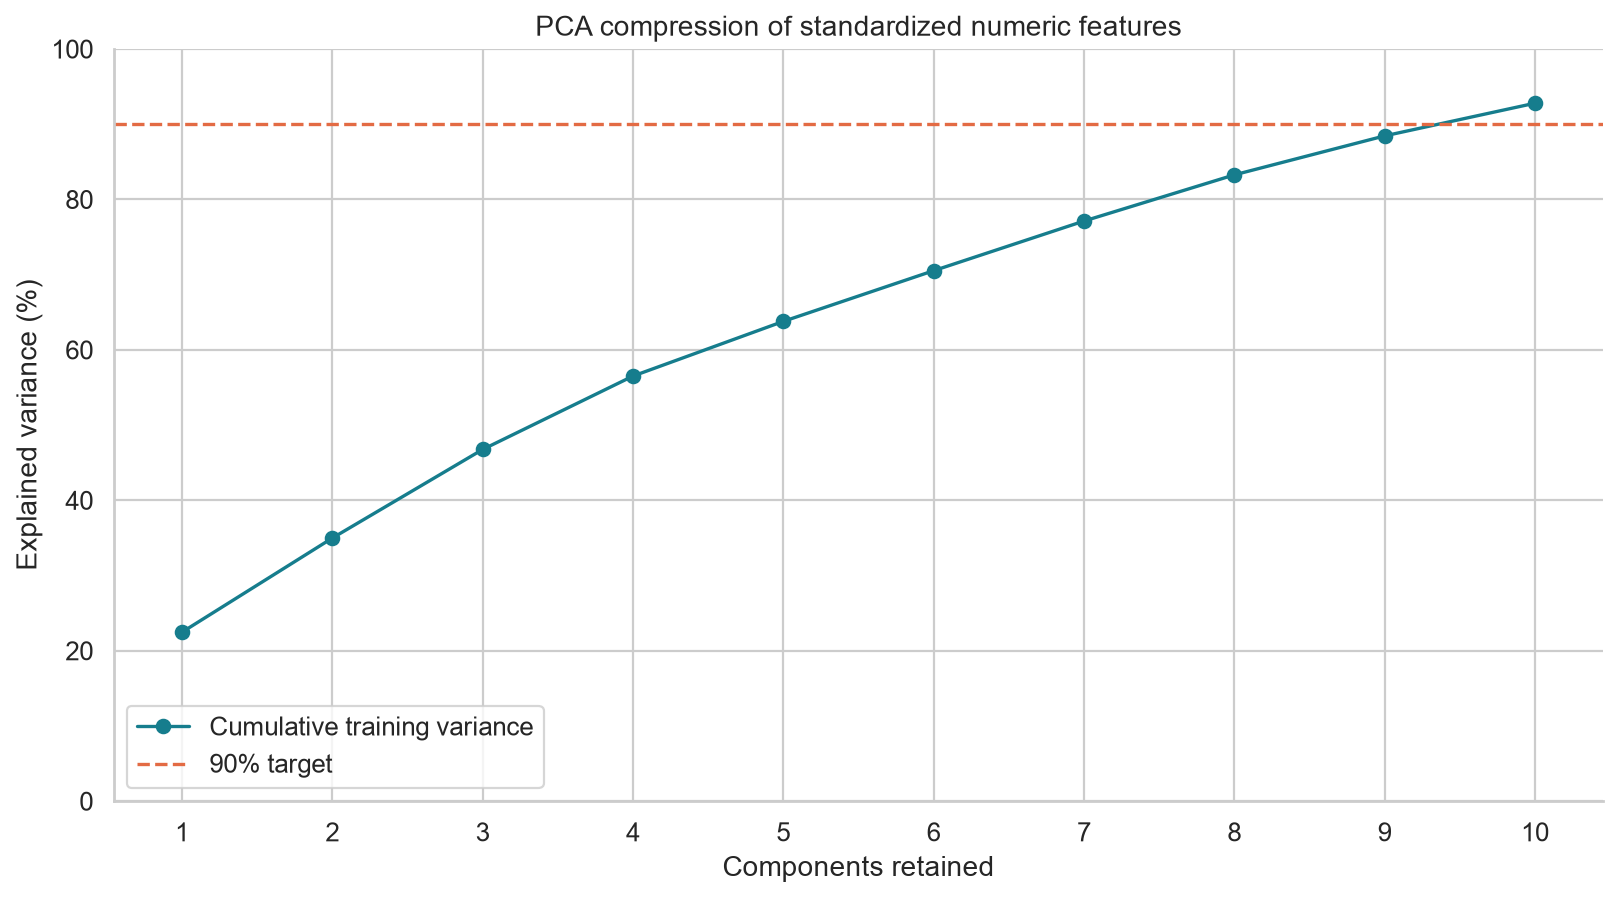

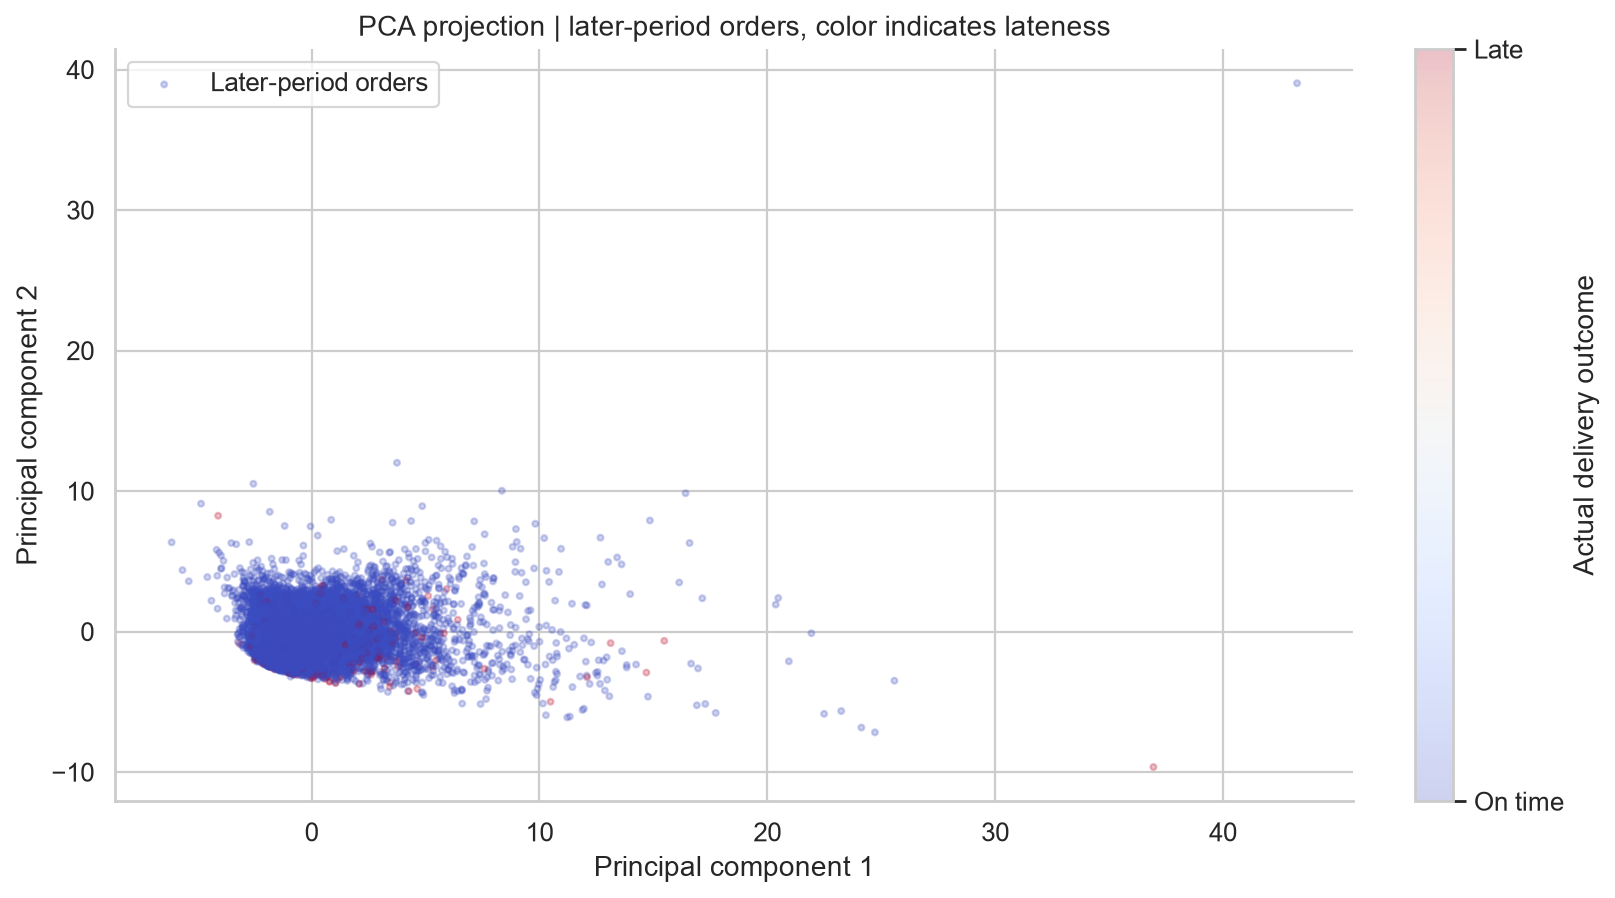

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
item_value,0.480,-0.128,0.061,-0.081,-0.038,0.003,-0.016,-0.050,0.402,0.132
freight,0.361,0.368,-0.184,0.190,-0.079,0.166,-0.144,0.041,-0.050,-0.046
item_count,0.162,0.266,-0.193,0.488,0.111,-0.102,0.084,0.039,-0.071,0.680
seller_count,0.064,0.139,-0.081,0.349,0.232,-0.505,0.475,-0.190,0.230,-0.472
weight_g,0.331,0.159,-0.103,0.247,-0.097,0.290,-0.265,0.152,-0.253,-0.522
interstate_share,0.088,0.413,-0.102,-0.479,-0.038,-0.086,0.145,-0.245,-0.139,0.099
promised_days,0.106,0.440,-0.054,-0.460,0.033,-0.144,0.111,0.042,-0.167,-0.062
freight_ratio,-0.230,0.413,-0.179,0.028,-0.166,0.193,-0.174,-0.052,0.628,-0.012
log_value,0.479,-0.158,0.073,-0.052,0.064,-0.106,0.099,-0.007,-0.236,0.083
value_per_item,0.445,-0.196,0.110,-0.202,-0.062,0.014,-0.024,-0.064,0.433,0.004


PC1 largest absolute loadings:


item_value        0.479799
log_value         0.479001
value_per_item    0.445111
freight           0.360569
weight_g          0.331258
Name: PC1, dtype: float64

PC2 largest absolute loadings:


promised_days       0.440059
freight_ratio       0.412991
interstate_share    0.412600
freight             0.367860
item_count          0.265938
Name: PC2, dtype: float64

In [10]:
show_chart("12_pca_variance.png")
show_chart("14_pca_projection.png")
display(model["loadings"].round(3))
for component in model["loadings"].columns[:2]:
    print(component, "largest absolute loadings:")
    display(model["loadings"][component].abs().nlargest(5))

## 7. When is feature engineering optional, and when is it essential?

Feature engineering is a nice-to-have when the source already expresses the
decision in useful variables, such as a tidy table of validated numerical
measurements, or a representation-learning model has sufficient data to learn
those patterns. Extra handcrafted inputs still need out-of-time validation.

It is essential when the raw representation cannot express the business unit or
mechanism. Here an order may have several item rows and sellers: order-level
counts and totals are necessary to avoid double counting. Freight/value exposes
shipping burden that two separate currency columns obscure. Cyclical month
encoding expresses calendar adjacency. Transformations also become essential
for scale-sensitive methods such as PCA. Feature timing is as important as feature
construction: a highly predictive review or delivery timestamp would invalidate
a purchase-time model.

## 8. Operational recommendations and next steps

Prioritize high-volume destinations with elevated late rates for route and
promise audits, then pilot communication or capacity changes with randomized
evaluation. Monitor delivery completion, review response, prevalence drift,
calibration and intervention cost. Use rolling temporal validation and carrier
information before choosing a deployment model. No cost savings or causal lift
are claimed from this observational dataset.

The optional Samand acquisition module is independent of this ecommerce analysis.
It collects 50 unique public cars manufactured strictly after Solar Hijri 1385,
records price/mileage/color/year/transmission/description, and retains source URLs
and acquisition timestamps. Negotiable and installment-only prices remain missing.
The snapshot is a convenience sample, not a representative Iranian price index.
See `docs/market_snapshot.md` for execution and coverage.